In [16]:
# Daily Challenge: Web Scraping and Data Visualization
# Your Task

# Instructions

#     Use this webpage : Tel Aviv - BBC Weather
# https://www.bbc.com/weather/293397

#     Scrape the Webpage: Use Python libraries like Selenium to interact with the webpage and BeautifulSoup to parse the HTML, Extract relevant data such as dates, numerical values, categories, etc., Organize the scraped data into a structured format.

In [1]:
# Install libraries (google-colab-selenium handles Chrome + driver automatically)
!pip install -q google-colab-selenium beautifulsoup4


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.3/510.3 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 60.2 MB/s eta 0:00:00


In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import google_colab_selenium as gs
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC


In [4]:
# Set up Selenium — google-colab-selenium handles Chrome, driver, and all options!
driver = gs.Chrome()
print("Selenium ready! Headless Chrome is running.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Selenium ready! Headless Chrome is running.


In [27]:
# The BBC weather website was not loading, so I m using a different weather site instead.



# Re-initialize driver (if necessary) and navigate
try:
    # This line is crucial to ensure the driver is active or re-initialized
    # If the driver object from `dl5_aLpE90tl` is still valid, it will be reused.
    # If it died, `gs.Chrome()` will attempt to start a new one.
    driver.quit() # Ensure any old session is closed before starting a new one
except Exception: # Catch any error if driver is already closed or not initialized
    pass
driver = gs.Chrome()

new_weather_url = 'https://worldweather.wmo.int/en/city.html?cityId=44'
print(f"Navigating to: {new_weather_url}")
driver.get(new_weather_url)
print(f"Current URL: {driver.current_url}")

# Wait for the climate table to be present
WebDriverWait(driver, 20).until(
    EC.presence_of_element_located((By.CLASS_NAME, 'climateTable'))
)
print("Climate table found on the page.")

# Get the page source after dynamic content has loaded
soup_wmo = BeautifulSoup(driver.page_source, 'html.parser')

# Extract the climate table
table = soup_wmo.find('table', class_='climateTable')

if table:
    headers = [th.get_text(strip=True).replace('\n', ' ').replace('(mm)', '(mm)').replace('(', ' (').replace('  ', ' ') for th in table.find('tr').find_all('th')]

    data = []
    for row in table.find_all('tr')[1:]:
        cols = row.find_all('td')
        cols = [ele.text.strip() for ele in cols]
        data.append([ele for ele in cols if ele])

# Data Analysis with Pandas:

#     Load your scraped data into a Pandas DataFrame.
#     Clean and preprocess the data if necessary (handling missing values, type conversion, etc.).
#     Perform basic analysis, such as calculating averages, totals, or trends over time.


    df_climate = pd.DataFrame(data, columns=headers)
    print("Scraped Climate Data For Tel Aviv:")
    display(df_climate.head(12))
else:
    print("Could not find the climateTable on the page.")
    df_climate = pd.DataFrame()


<IPython.core.display.Javascript object>

Navigating to: https://worldweather.wmo.int/en/city.html?cityId=44
Current URL: https://worldweather.wmo.int/en/city.html?cityId=44
Climate table found on the page.
Scraped Climate Data For Tel Aviv:


,Month,Mean Daily Minimum Temperature (°C),Mean Daily Maximum Temperature (°C),Mean Total Rainfall (mm),Mean Number of Rain Days
0,Jan,9.8,17.5,147.1,12.8
1,Feb,9.8,18.0,111.0,10.5
2,Mar,11.7,19.9,62.0,7.7
3,Apr,14.2,22.9,16.0,2.3
4,May,17.1,25.4,3.6,0.8
5,Jun,20.4,27.3,0.1,0.1
6,Jul,23.0,29.4,0.0,0.0
7,Aug,23.4,29.8,0.0,0.0
8,Sep,21.7,29.0,0.7,0.3
9,Oct,18.8,26.8,34.3,3.6


In [30]:
# Data Cleaning and Preprocessing


if not df_climate.empty:
    # Clean headers for easier use
    df_climate.columns = ['Month', 'Min Daily Temp (°C)', 'Max Daily Temp (°C)', 'Total Rainfall (mm)', 'Number of Rain Days']

    # Convert numerical columns to numeric type
    for col in ['Min Daily Temp (°C)', 'Max Daily Temp (°C)', 'Total Rainfall (mm)', 'Number of Rain Days']:
        df_climate[col] = pd.to_numeric(df_climate[col], errors='coerce')

    print("Cleaned Climate Data (Mean Values):")
    display(df_climate)
else:
    print("DataFrame is empty, skipping cleaning and preprocessing.")

Cleaned Climate Data (Mean Values):


,Month,Min Daily Temp (°C),Max Daily Temp (°C),Total Rainfall (mm),Number of Rain Days
0,Jan,9.8,17.5,147.1,12.8
1,Feb,9.8,18.0,111.0,10.5
2,Mar,11.7,19.9,62.0,7.7
3,Apr,14.2,22.9,16.0,2.3
4,May,17.1,25.4,3.6,0.8
5,Jun,20.4,27.3,0.1,0.1
6,Jul,23.0,29.4,0.0,0.0
7,Aug,23.4,29.8,0.0,0.0
8,Sep,21.7,29.0,0.7,0.3
9,Oct,18.8,26.8,34.3,3.6


### Data Analysis

Let's perform some basic analysis on the cleaned climate data, such as calculating overall averages and identifying extreme values.

In [31]:
if not df_climate.empty:
    # Calculate overall average temperatures and rainfall
    overall_avg_min_temp = df_climate['Min Daily Temp (°C)'].mean()
    overall_avg_max_temp = df_climate['Max Daily Temp (°C)'].mean()
    overall_avg_rainfall = df_climate['Total Rainfall (mm)'].mean()
    overall_avg_rain_days = df_climate['Number of Rain Days'].mean()

    print(f"Overall Average Minimum Daily Temperature: {overall_avg_min_temp:.2f}°C")
    print(f"Overall Average Maximum Daily Temperature: {overall_avg_max_temp:.2f}°C")
    print(f"Overall Average Total Monthly Rainfall: {overall_avg_rainfall:.2f} mm")
    print(f"Overall Average Number of Monthly Rain Days: {overall_avg_rain_days:.2f}")

    # Find the month with the highest/lowest temperatures and rainfall
    month_max_temp = df_climate.loc[df_climate['Max Daily Temp (°C)'].idxmax()]
    month_min_temp = df_climate.loc[df_climate['Min Daily Temp (°C)'].idxmin()]
    month_max_rainfall = df_climate.loc[df_climate['Total Rainfall (mm)'].idxmax()]
    month_min_rainfall = df_climate.loc[df_climate['Total Rainfall (mm)'].idxmin()]

    print(f"\nMonth with Highest Max Daily Temperature: {month_max_temp['Month']} ({month_max_temp['Max Daily Temp (°C)']}°C)")
    print(f"Month with Lowest Min Daily Temperature: {month_min_temp['Month']} ({month_min_temp['Min Daily Temp (°C)']}°C)")
    print(f"Month with Highest Total Rainfall: {month_max_rainfall['Month']} ({month_max_rainfall['Total Rainfall (mm)']} mm)")
    print(f"Month with Lowest Total Rainfall: {month_min_rainfall['Month']} ({month_min_rainfall['Total Rainfall (mm)']} mm)")
else:
    print("DataFrame is empty, skipping data analysis.")

Overall Average Minimum Daily Temperature: 16.37°C
Overall Average Maximum Daily Temperature: 24.12°C
Overall Average Total Monthly Rainfall: 48.55 mm
Overall Average Number of Monthly Rain Days: 4.64

Month with Highest Max Daily Temperature: Aug (29.8°C)
Month with Lowest Min Daily Temperature: Jan (9.8°C)
Month with Highest Total Rainfall: Jan (147.1 mm)
Month with Lowest Total Rainfall: Jul (0.0 mm)


### Data Visualization with Seaborn and Matplotlib

Now, let's create some visualizations to better understand the climate patterns, such as temperature and rainfall trends over the months.

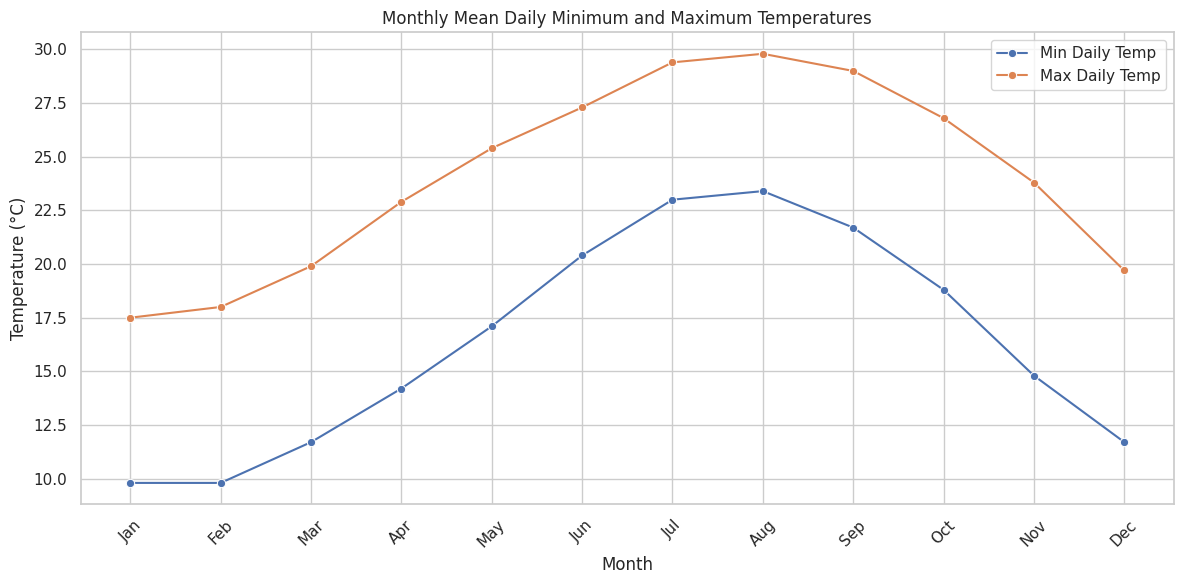

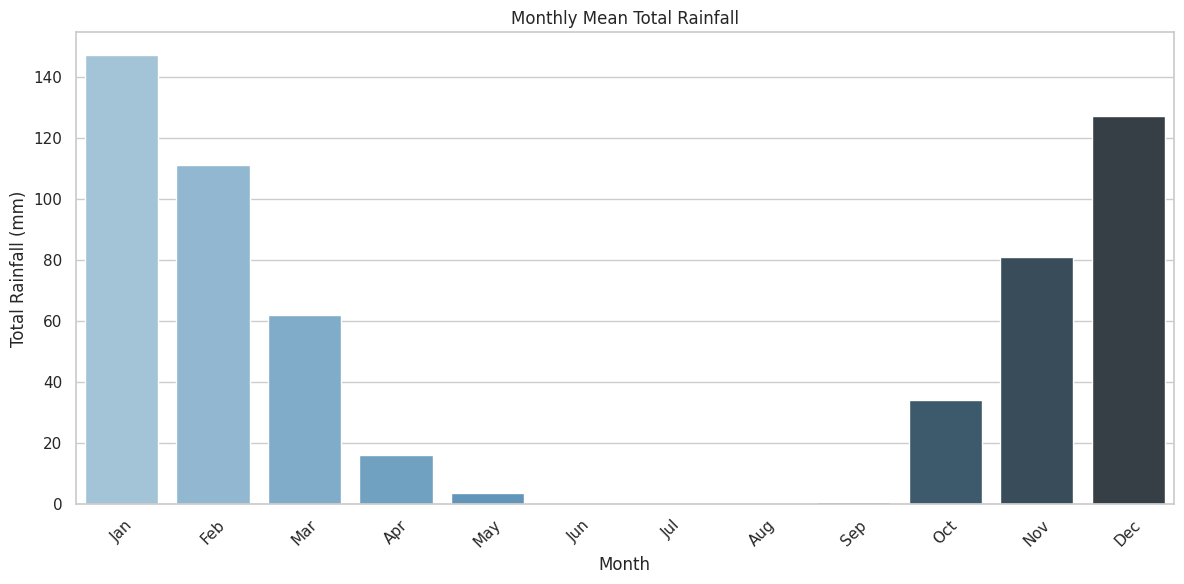

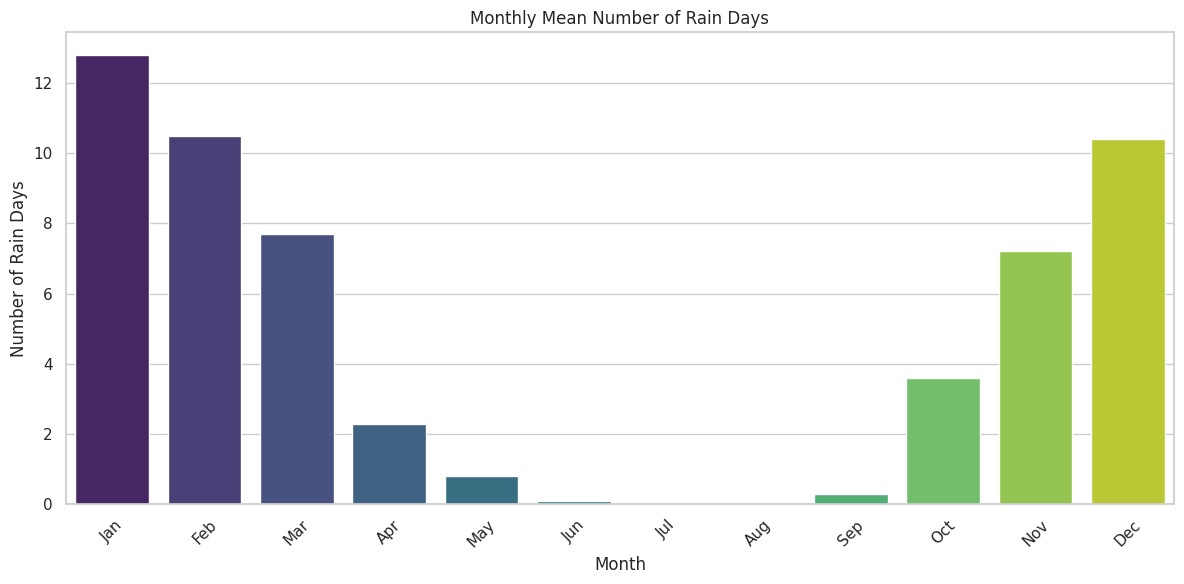

In [35]:
#     Data Visualization with Seaborn and Matplotlib:
#         Use Seaborn and Matplotlib to create visualizations that provide insights into the data.
#         Examples of visualizations can include line plots for trends over time, bar charts for comparing categories, or heatmaps for showing data density.
#         Ensure your visualizations are well-labeled with clear titles, axis labels, and legends where appropriate.

import matplotlib.pyplot as plt
import seaborn as sns

if not df_climate.empty:
    # Set the aesthetic style of the plots
    sns.set_theme(style="whitegrid")

    # Prepare data for plotting by ensuring Month is a categorical type for proper ordering
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    df_climate['Month'] = pd.Categorical(df_climate['Month'], categories=month_order, ordered=True)
    df_climate = df_climate.sort_values('Month')

    # 1. Temperature Trends (Min and Max Daily Temperature)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_climate, x='Month', y='Min Daily Temp (°C)', marker='o', label='Min Daily Temp')
    sns.lineplot(data=df_climate, x='Month', y='Max Daily Temp (°C)', marker='o', label='Max Daily Temp')
    plt.title('Monthly Mean Daily Minimum and Maximum Temperatures')
    plt.xlabel('Month')
    plt.ylabel('Temperature (°C)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2. Total Rainfall per Month
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_climate, x='Month', y='Total Rainfall (mm)', palette='Blues_d', hue='Month', legend=False)
    plt.title('Monthly Mean Total Rainfall')
    plt.xlabel('Month')
    plt.ylabel('Total Rainfall (mm)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 3. Number of Rain Days per Month
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_climate, x='Month', y='Number of Rain Days', palette='viridis', hue='Month', legend=False)
    plt.title('Monthly Mean Number of Rain Days')
    plt.xlabel('Month')
    plt.ylabel('Number of Rain Days')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame is empty, skipping data visualization.")

In [ ]:
# Document Your Findings:

#     Create a report summarizing your methodology, analysis, and insights from the visualizations.
#     Explain any interesting patterns or insights derived from your data.


### Document Your Findings

Here's a summary of the methodology, analysis, and insights derived from the data and visualizations.

**Methodology:**

1.  **Data Acquisition:** The climate data for Tel Aviv was scraped from `https://worldweather.wmo.int/en/city.html?cityId=44` using Selenium to interact with the webpage and BeautifulSoup to parse the HTML and extract the `climateTable`.
2.  **Data Structuring:** The extracted table data was loaded into a Pandas DataFrame, with columns representing `Month`, `Min Daily Temp (°C)`, `Max Daily Temp (°C)`, `Total Rainfall (mm)`, and `Number of Rain Days`.
3.  **Data Cleaning:** Column headers were standardized, and numerical data was converted from string to numeric types to facilitate calculations and visualizations.

**Analysis and Insights:**

*   **Temperature Trends:**
    *   The line plot clearly shows a distinct seasonal temperature cycle. Minimum and maximum daily temperatures are lowest during the winter months (December to February) and steadily rise, peaking in the summer months (July and August).
    *   August experiences the highest mean daily maximum temperature (29.8°C), while January has the lowest mean daily minimum temperature (9.8°C).
    *   The temperature difference between minimum and maximum is relatively consistent throughout the year, suggesting a steady diurnal range.

*   **Rainfall Patterns:**
    *   The bar chart for total rainfall highlights a significant wet season and a dry season.
    *   January is the wettest month with the highest total rainfall (147.1 mm) and the most rain days (12.8 days), followed by December and February.
    *   The summer months (June, July, August) are almost entirely dry, with negligible rainfall (0.0-0.1 mm) and very few, if any, rain days.
    *   There's a rapid decrease in rainfall from spring to early summer and a gradual increase from autumn to winter.

*   **Overall Averages:**
    *   The overall average minimum daily temperature is approximately 16.37°C.
    *   The overall average maximum daily temperature is approximately 24.12°C.
    *   The overall average total rainfall is about 48.55 mm per month.
    *   On average, there are about 4.64 rain days per month.

**Summary:**

Tel Aviv exhibits a typical Mediterranean climate with hot, dry summers and mild, wet winters. The visualizations effectively illustrate these patterns, showing clear peaks in temperature during summer and peaks in rainfall during winter. This information is valuable for understanding seasonal variations and for planning activities sensitive to weather conditions.